<a href="https://colab.research.google.com/github/Jenyy0416/cs1090b_project/blob/tiff/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS 1090B Project Milestone 2

*Group project number:* 41

*Group members:* You Wu, Jenny Yang, Xuyang Sun, Yifan Xu, Jiaxi Liu

## Data Description

test

## Data Exploration & Preprocessing

In [ ]:
# load the dataset from Hugging Face
from datasets import load_dataset

# import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import random
import torch
import io
from PIL import Image
from collections import Counter
from pathlib import Path
import re
from wordcloud import WordCloud

# set random seeds for reproducibility
random.seed(109)
np.random.seed(109)
torch.manual_seed(109)


In [ ]:
ds = load_dataset("ykumards/open-i")
ds['train'].to_pandas().head()

README.md: 0.00B [00:00, ?B/s]

C:\Users\noa_w\AppData\Roaming\Python\Python310\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\noa_w\.cache\huggingface\hub\datasets--ykumards--open-i. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00005-c80629f6027d8e(…):   0%|          | 0.00/425M [00:00<?, ?B/s]

data/train-00001-of-00005-07e6c158a3f561(…):   0%|          | 0.00/418M [00:00<?, ?B/s]

KeyboardInterrupt: 

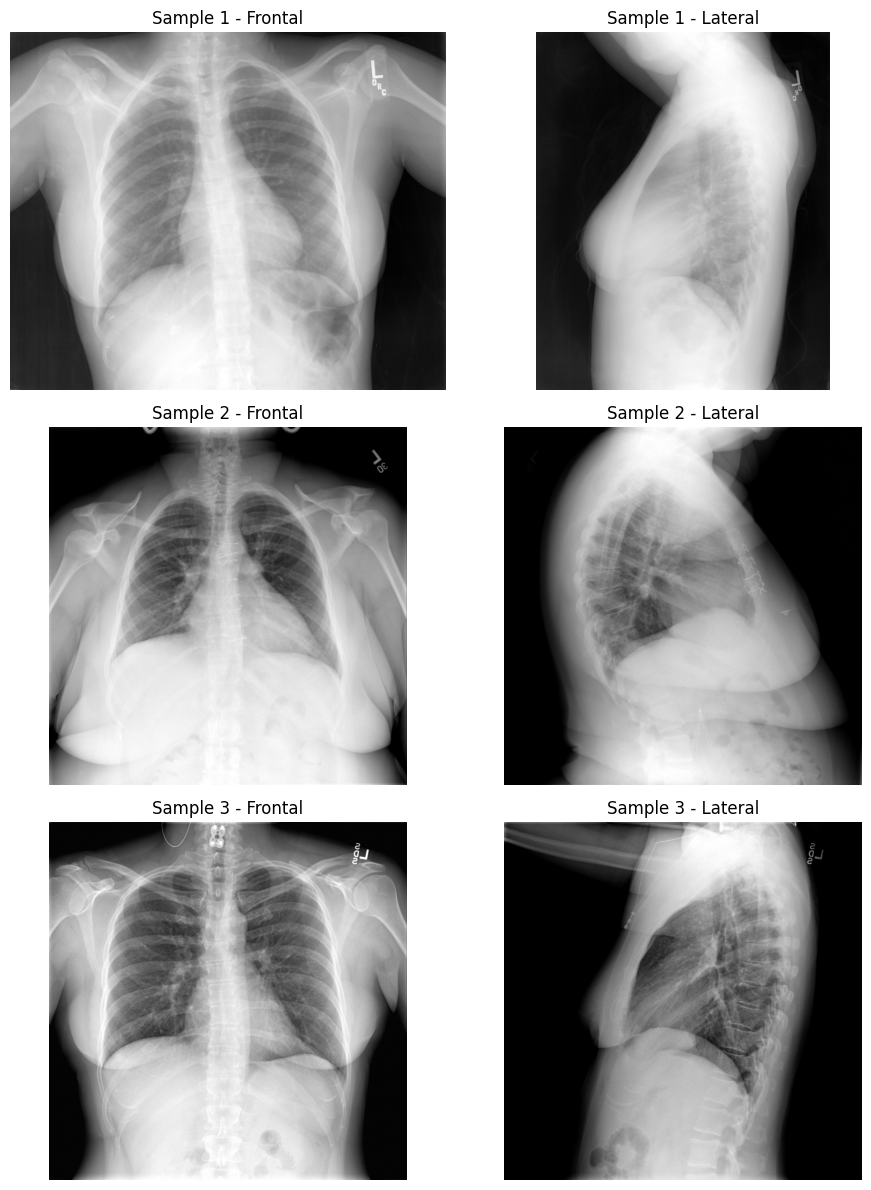

In [ ]:
def load_image_from_byte_array(byte_array):
    return Image.open(io.BytesIO(byte_array))

# Display first 3 samples with frontal and lateral images
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for i in range(3):
    img_frontal = load_image_from_byte_array(ds['train'][i]['img_frontal'])
    img_lateral = load_image_from_byte_array(ds['train'][i]['img_lateral'])

    # plot frontal
    axes[i, 0].imshow(img_frontal, cmap="gray")
    axes[i, 0].set_title(f"Sample {i+1} - Frontal")
    axes[i, 0].axis("off")

    # plot lateral
    axes[i, 1].imshow(img_lateral, cmap="gray")
    axes[i, 1].set_title(f"Sample {i+1} - Lateral")
    axes[i, 1].axis("off")

# display
plt.tight_layout()
plt.show()


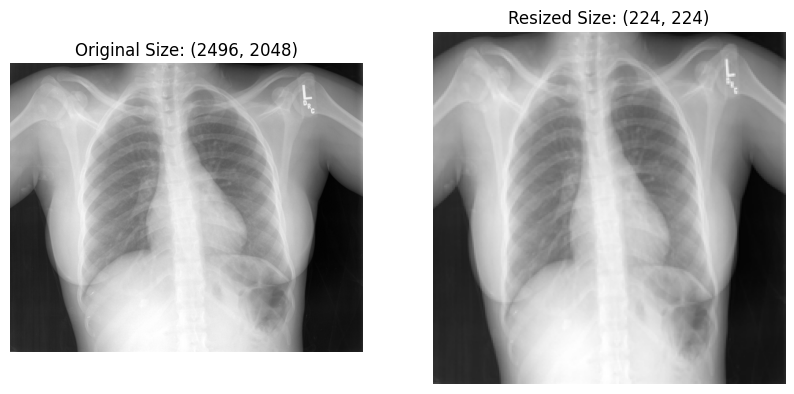

In [ ]:
def preprocess_image(byte_array, size=(224, 224)):
    # Load image from bytes
    img = Image.open(io.BytesIO(byte_array)).convert("RGB")
    # Resize image
    img_resized = img.resize(size, Image.Resampling.LANCZOS)
    return img_resized

# Example: Resize the first frontal image
sample_byte_array = ds['train'][0]['img_frontal']
resized_img = preprocess_image(sample_byte_array)

# Display original vs resized for comparison (visualizing size change)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

original_img = Image.open(io.BytesIO(sample_byte_array))
ax[0].imshow(original_img, cmap="gray")
ax[0].set_title(f"Original Size: {original_img.size}")
ax[0].axis("off")

ax[1].imshow(resized_img)
ax[1].set_title(f"Resized Size: {resized_img.size}")
ax[1].axis("off")

plt.show()

In [ ]:
df = ds['train'].to_pandas().copy()
image_cols = ["img_frontal", "img_lateral"]

for col in image_cols:
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in dataframe.")

In [ ]:
def has_image(byte_array):
    return byte_array is not None and len(byte_array) > 0

df["has_frontal"] = df["img_frontal"].apply(has_image)
df["has_lateral"] = df["img_lateral"].apply(has_image)

df["num_images"] = df["has_frontal"].astype(int) + df["has_lateral"].astype(int)

def image_case(row):
    if row["has_frontal"] and row["has_lateral"]:
        return "both_images"
    elif row["has_frontal"] and not row["has_lateral"]:
        return "frontal_only"
    elif not row["has_frontal"] and row["has_lateral"]:
        return "lateral_only"
    else:
        return "no_image"

df["image_case"] = df.apply(image_case, axis=1)

In [ ]:
image_case_summary = (
    df["image_case"]
    .value_counts(dropna=False)
    .rename_axis("image_case")
    .reset_index(name="count")
)

image_case_summary["percent"] = (image_case_summary["count"] / len(df) * 100).round(2)

print("=== Image Availability Summary ===")
display(image_case_summary)

print("\n=== Number of Images per Sample ===")
display(
    df["num_images"]
    .value_counts()
    .sort_index()
    .rename_axis("num_images")
    .reset_index(name="count")
)

=== Image Availability Summary ===


,image_case,count,percent
0,both_images,3388,87.98
1,frontal_only,301,7.82
2,lateral_only,162,4.21



=== Number of Images per Sample ===


,num_images,count
0,1,463
1,2,3388


In [ ]:
key_cols = ["img_frontal", "img_lateral", "findings", "impression", "MeSH", "Problems"]

for col in key_cols:
    values = df[col]
    missing_count = sum(x is None or str(x).strip() == "" for x in values)
    print(col, missing_count, missing_count / len(values))

img_frontal 162 0.04206699558556219
img_lateral 301 0.07816151648922358
findings 514 0.13347182549987016
impression 31 0.00804985717995326
MeSH 0 0.0
Problems 0 0.0


In [ ]:
def is_missing(x):
    if x is None:
        return True
    if isinstance(x, str):
        return x.strip() == ""
    if isinstance(x, list):
        return len(x) == 0
    return False

In [ ]:
for col in key_cols:
    values = df[col]
    missing_count = sum(is_missing(x) for x in values)
    print(f"{col}: {missing_count} ({missing_count/len(values):.2%})")

img_frontal: 162 (4.21%)
img_lateral: 301 (7.82%)
findings: 514 (13.35%)
impression: 31 (0.80%)
MeSH: 0 (0.00%)
Problems: 0 (0.00%)


Map:   0%|          | 0/3851 [00:00<?, ? examples/s]

Skipping UID 44: cannot identify image file <_io.BytesIO object at 0x77fbe592fd80>
Skipping UID 45: cannot identify image file <_io.BytesIO object at 0x77fbe592fce0>
Skipping UID 60: cannot identify image file <_io.BytesIO object at 0x77fbe592f830>
Skipping UID 68: cannot identify image file <_io.BytesIO object at 0x77fbe592fce0>
Skipping UID 71: cannot identify image file <_io.BytesIO object at 0x77fbe592fb00>
Skipping UID 73: cannot identify image file <_io.BytesIO object at 0x77fbe592fb00>
Skipping UID 74: cannot identify image file <_io.BytesIO object at 0x77fbe592fb00>
Skipping UID 81: cannot identify image file <_io.BytesIO object at 0x77fbe592fce0>
Skipping UID 88: cannot identify image file <_io.BytesIO object at 0x77fc6419e200>
Skipping UID 91: cannot identify image file <_io.BytesIO object at 0x77fc6419e200>
Skipping UID 104: cannot identify image file <_io.BytesIO object at 0x77fc6419e200>
Skipping UID 119: cannot identify image file <_io.BytesIO object at 0x77fbe592fce0>
Sk

Filter:   0%|          | 0/3851 [00:00<?, ? examples/s]

3851
3388
(224, 224)


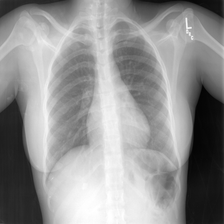

In [ ]:
from datasets import Features, Image as HFImage
import PIL

def transform_images(example):
    try:
        example['img_frontal_processed'] = preprocess_image(example['img_frontal'])
        example['img_lateral_processed'] = preprocess_image(example['img_lateral'])
        example['is_valid'] = True
    except (PIL.UnidentifiedImageError, ValueError, TypeError) as e:
        example['img_frontal_processed'] = None
        example['img_lateral_processed'] = None
        example['is_valid'] = False
        print(f"Skipping UID {example.get('uid', 'Unknown')}: {e}")
    return example

ds_processed = ds['train'].map(transform_images)

ds_cleaned = ds_processed.filter(lambda x: x['is_valid'])

print(len(ds['train']))
print(len(ds_cleaned))

if len(ds_cleaned) > 0:
    sample = ds_cleaned[0]
    print(sample['img_frontal_processed'].size)
    display(sample['img_frontal_processed'])


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# ds_cleaned.save_to_disk("/content/drive/MyDrive/cs109b_project/ds_cleaned_hf")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving the dataset (0/5 shards):   0%|          | 0/3388 [00:00<?, ? examples/s]

In [ ]:
from datasets import load_from_disk

ds_clean = load_from_disk("/content/drive/MyDrive/cs109b_project/ds_cleaned_hf")
type(ds_clean)

datasets.arrow_dataset.Dataset

In [ ]:
# Inspect internal information of ds_clean
print(f"Total number of samples: {len(ds_clean)}")
print(f"Column names (features) in dataset: {ds_clean.column_names}")

# Get the first sample for detailed inspection
first_sample = ds_clean[0]

# Check image dimensions (using frontal image as an example)
if 'img_frontal_processed' in first_sample:
    img = first_sample['img_frontal_processed']
    print(f"Image type: {type(img)}")
    print(f"Frontal image size: {img.size}")
else:
    print("Preprocessed image column not found.")

# Display UIDs for the first 5 samples (acting as image identifiers)
print(f"UIDs of the first 5 samples: {ds_clean['uid'][:5]}")

Total number of samples: 3388
Column names (features) in dataset: ['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison', 'findings', 'impression', 'img_frontal', 'img_lateral', 'img_frontal_processed', 'img_lateral_processed', 'is_valid']
Image type: <class 'PIL.PngImagePlugin.PngImageFile'>
Frontal image size: (224, 224)
UIDs of the first 5 samples: [1, 2, 3, 4, 5]


In [ ]:
import re
import pandas as pd
from collections import Counter

def is_empty_text(text):
    return text is None or str(text) == ""

def is_whitespace_only(text):
    return text is not None and str(text) != "" and str(text).strip() == ""

def word_count(text):
    if text is None:
        return 0
    return len(str(text).strip().split())

def has_suspicious_chars(text):
    if text is None:
        return False

    text = str(text)

    suspicious_patterns = [
        r"�",
        r"[^\x00-\x7F]{8,}",
        r"[_*#@~]{4,}",
        r"[!?.,]{5,}",
    ]

    for pattern in suspicious_patterns:
        if re.search(pattern, text):
            return True
    return False

In [ ]:
def clean_text(text):
    if text is None:
        return None

    text = str(text)
    text = text.strip()

    text = re.sub(r"[\n\r\t]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    text = text.lower()

    return text

In [ ]:
def text_quality_summary(dataset, col_name, short_threshold=3, long_threshold=80):
    texts = dataset[col_name]
    total = len(texts)

    empty_count = sum(is_empty_text(x) for x in texts)
    whitespace_count = sum(is_whitespace_only(x) for x in texts)

    lengths = [word_count(x) for x in texts if x is not None and str(x).strip() != ""]
    short_count = sum(1 for x in texts if word_count(x) > 0 and word_count(x) < short_threshold)
    long_count = sum(1 for x in texts if word_count(x) > long_threshold)
    suspicious_count = sum(has_suspicious_chars(x) for x in texts)

    summary = {
        "column": col_name,
        "total_samples": total,
        "empty_count": empty_count,
        "whitespace_only_count": whitespace_count,
        "short_count": short_count,
        "long_count": long_count,
        "suspicious_char_count": suspicious_count,
        "mean_length": round(sum(lengths) / len(lengths), 2) if lengths else 0,
        "max_length": max(lengths) if lengths else 0,
        "min_length_nonempty": min(lengths) if lengths else 0
    }

    return pd.DataFrame([summary])

In [ ]:
findings_summary = text_quality_summary(ds_clean, "findings")
impression_summary = text_quality_summary(ds_clean, "impression")

summary_df = pd.concat([findings_summary, impression_summary], ignore_index=True)
print(summary_df)

       column  total_samples  empty_count  whitespace_only_count  short_count  \
0    findings           3388          445                      0            0   
1  impression           3388           18                      0           90   

   long_count  suspicious_char_count  mean_length  max_length  \
0          23                      0        30.96         149   
1           5                      0        10.38         130   

   min_length_nonempty  
0                    7  
1                    1  


In [ ]:
short_findings = [x for x in ds_clean["findings"] if 0 < word_count(x) < 3]
short_impression = [x for x in ds_clean["impression"] if 0 < word_count(x) < 3]

print("Short findings examples:", short_findings[:10])
print("Short impression examples:", short_impression[:10])

Short findings examples: []
Short impression examples: ['Clear lungs.', 'Normal chest.', 'Clear lungs', 'Normal chest', 'Normal chest', 'Clear lungs.', '1. Cardiomegaly', 'Clear lungs.', 'Clear lungs.', 'Normal chest.']


In [ ]:
# Find impressions that start with a digit
numeric_start_impressions = [x for x in ds_clean['impression'] if x is not None and len(str(x).strip()) > 0 and str(x).strip()[0].isdigit()]

print(f"Total impressions starting with a number: {len(numeric_start_impressions)}")
print("\nFirst 20 examples:")
for imp in numeric_start_impressions[:20]:
    print(f"- {imp}")

Total impressions starting with a number: 663

First 20 examples:
- 1. Bullous emphysema and interstitial fibrosis. 2. Probably scarring in the left apex, although difficult to exclude a cavitary lesion. 3. Opacities in the bilateral upper lobes could represent scarring, however the absence of comparison exam, recommend short interval followup radiograph or CT thorax to document resolution.
- 1. Left lower lobe airspace disease and bilateral pleural effusions, left greater than right. This may be secondary to inhalational injury. Recommend followup to ensure complete resolution.
- 1. Interval improvement in consolidative left base opacity. Multifocal scattered bibasilar patchy and XXXX pulmonary opacities again noted, most consistent with atelectasis/infiltrate. 2. Stable enlarged cardiomediastinal silhouette. Stable pulmonary vascular congestion. .
- 1. Slight interval worsening of the diffusely increased bilateral pulmonary interstitial markings, greatest in the peripheral aspect of 

In [ ]:
def clean_text_with_custom_sep(text, separator=" [SEP] "):
    if text is None:
        return ""

    text = str(text).strip()

    # 1. Remove the leading '1.' or '1)' marker
    first_marker_pattern = r'^1[\.\)]\s*'
    text = re.sub(first_marker_pattern, "", text)

    # 2. Replace subsequent markers (2., 3., etc.) with the separator
    subsequent_markers_pattern = r'\s*\d+[\.\)]\s*'
    text = re.sub(subsequent_markers_pattern, separator, text)
    text = re.sub(r'\.\s*\.$', '.', text)

    # 3. Clean up extra whitespace
    text = text.strip()
    return re.sub(r'\s+', ' ', text)

# Function to apply the cleaning to the dataset
def apply_refined_cleaning(example):
    example['findings_refined'] = clean_text_with_custom_sep(example['findings'])
    example['impression_refined'] = clean_text_with_custom_sep(example['impression'])
    return example

In [ ]:
# Execute the mapping process
ds_clean = ds_clean.map(apply_refined_cleaning)

# Validation: View the first 5 samples that originally had numbered impressions
print("=== Refined Cleaning Examples (Removed '1.', replaced others with '[SEP]') ===")
check_df = ds_clean.to_pandas()
mask = check_df['impression'].str.contains(r'^1[\.\)]', na=False, regex=True)
display(check_df[mask][['impression', 'impression_refined']].head())

Map:   0%|          | 0/3388 [00:00<?, ? examples/s]

=== Refined Cleaning Examples (Removed '1.', replaced others with '[SEP]') ===


,impression,impression_refined
3,1. Bullous emphysema and interstitial fibrosis...,Bullous emphysema and interstitial fibrosis. [...
24,1. Left lower lobe airspace disease and bilate...,Left lower lobe airspace disease and bilateral...
27,1. Interval improvement in consolidative left ...,Interval improvement in consolidative left bas...
40,1. Slight interval worsening of the diffusely ...,Slight interval worsening of the diffusely inc...
45,1. No evidence of acute cardiopulmonary proces...,No evidence of acute cardiopulmonary process. ...


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
# Inspect the new columns and compare with originals for a few samples
final_check_df = ds_clean.to_pandas()

# Selecting columns to display
cols_to_show = ['uid', 'findings', 'findings_refined', 'impression', 'impression_refined']

print("Total samples in ds_clean:", len(ds_clean))
print("Columns in ds_clean:", ds_clean.column_names)

# Displaying 5 samples where numbering was present to verify the transformation
mask_with_numbers = final_check_df['impression'].str.contains(r'^1[\.\)]', na=False, regex=True)
display(final_check_df[mask_with_numbers][cols_to_show].head())

Total samples in ds_clean: 3388
Columns in ds_clean: ['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison', 'findings', 'impression', 'img_frontal', 'img_lateral', 'img_frontal_processed', 'img_lateral_processed', 'is_valid', 'findings_refined', 'impression_refined']


,uid,findings,findings_refined,impression,impression_refined
3,4,There are diffuse bilateral interstitial and a...,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...,Bullous emphysema and interstitial fibrosis. [...
24,25,The heart is within normal limits in size. Sur...,The heart is within normal limits in size. Sur...,1. Left lower lobe airspace disease and bilate...,Left lower lobe airspace disease and bilateral...
27,28,Bilateral patchy pulmonary opacities noted. In...,Bilateral patchy pulmonary opacities noted. In...,1. Interval improvement in consolidative left ...,Interval improvement in consolidative left bas...
40,41,The cardiomediastinal silhouette is stable in ...,The cardiomediastinal silhouette is stable in ...,1. Slight interval worsening of the diffusely ...,Slight interval worsening of the diffusely inc...
45,48,The cardiac and mediastinal contours are withi...,The cardiac and mediastinal contours are withi...,1. No evidence of acute cardiopulmonary proces...,No evidence of acute cardiopulmonary process. ...


In [ ]:
def get_unique_categories(df, column_name):
    # Flatten all categories by splitting on ';' and stripping whitespace
    all_labels = []
    for entry in df[column_name].dropna():
        labels = [label.strip() for label in str(entry).split(';') if label.strip()]
        all_labels.extend(labels)

    # Count frequencies
    counts = Counter(all_labels)
    return pd.DataFrame(counts.items(), columns=['Category', 'Count']).sort_values(by='Count', ascending=False)

# Analyze MeSH
mesh_counts = get_unique_categories(df, 'MeSH')
# Analyze Problems
problems_counts = get_unique_categories(df, 'Problems')

print(f"Unique categories in MeSH: {len(mesh_counts)}")
print(f"Unique categories in Problems: {len(problems_counts)}")

print("\n=== Top 10 MeSH Categories ===")
display(mesh_counts.head(10))

print("\n=== Top 10 Problems Categories ===")
display(problems_counts.head(10))

Unique categories in MeSH: 1681
Unique categories in Problems: 121

=== Top 10 MeSH Categories ===


,Category,Count
0,normal,1379
66,Lung/hypoinflation,238
30,Lung/hyperdistention,159
57,Cardiomegaly,139
103,Cardiomegaly/mild,129
82,Aorta/tortuous,118
24,Thoracic Vertebrae/degenerative,114
65,Spine/degenerative,109
21,Granulomatous Disease,93
51,No Indexing,92



=== Top 10 Problems Categories ===


,Category,Count
0,normal,1379
10,Lung,553
7,Opacity,509
1,Cardiomegaly,345
46,Calcinosis,332
11,Pulmonary Atelectasis,330
14,Calcified Granuloma,276
21,Thoracic Vertebrae,256
6,Cicatrix,196
42,Spine,174


## Image EDA

In [ ]:
NOTEBOOK_ROOT = Path.cwd()
DATA_DIR = NOTEBOOK_ROOT / "ds_cleaned_hf"

dataset = load_dataset(
    "arrow",
    data_files={
        "train": [
            str(DATA_DIR / f"data-0000{i}-of-00005.arrow")
            for i in range(5)
        ]
    }
)

data = dataset["train"]

Generating train split: 0 examples [00:00, ? examples/s]

### Sample Visualization

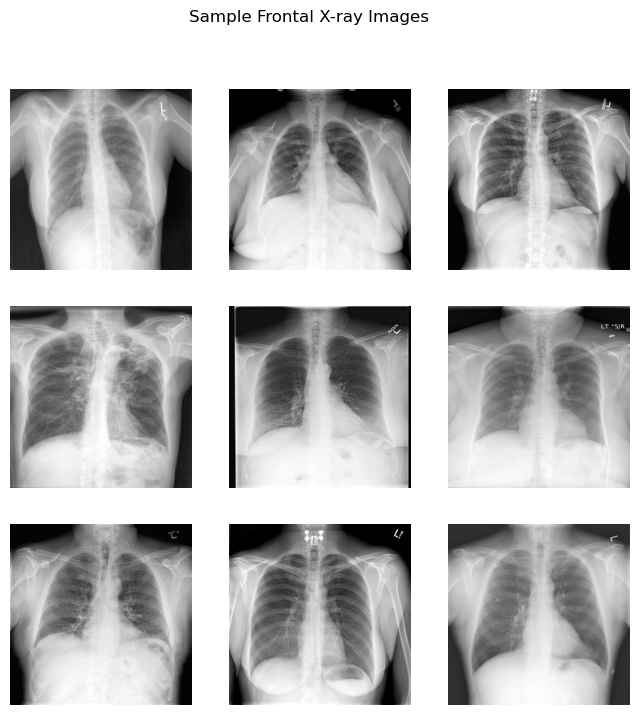

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    img = data[i]["img_frontal_processed"]
    ax.imshow(img)
    ax.axis("off")

plt.suptitle("Sample Frontal X-ray Images")
plt.show()

The sample frontal X-ray images show consistent anatomical structures, including clear lung fields, rib boundaries, and heart silhouettes.

There is visible variability across samples, with some images showing potential abnormalities such as opacities or asymmetry, suggesting the dataset contains both normal and pathological cases.

The images are centered and aligned, indicating successful preprocessing and suitability for downstream modeling.

In [ ]:
sizes = []

for i in range(len(data)):
    img = data[i]["img_frontal_processed"]
    sizes.append(img.size)

set(sizes)

{(224, 224)}

### Pixel Intensity Distribution

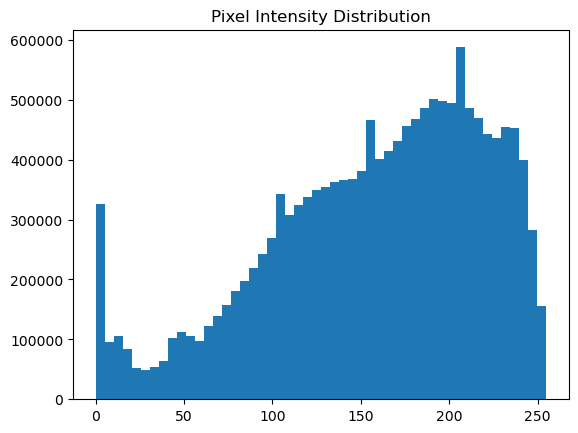

In [ ]:
pixels = []

for i in range(100):
    img = np.array(data[i]["img_frontal_processed"])
    pixels.extend(img.flatten())

plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

The pixel intensity distribution spans the full grayscale range (0–255), indicating that the images preserve sufficient contrast information.

The distribution is skewed toward higher intensity values, which is expected in chest X-rays due to large bright regions such as bones and background areas.

The absence of extreme spikes or degenerate distributions suggests that the images are not corrupted and have been properly normalized.

In [ ]:
means = []
for i in range(100):
    img = np.array(data[i]["img_frontal_processed"])
    means.append(img.mean())

print(np.mean(means), np.std(means))

158.0097532684949 16.440003014495094


The average pixel intensity across sampled images is approximately 158 with a standard deviation of 16.4.

The relatively high mean intensity reflects the presence of bright regions such as bones and background in chest X-ray images.

The low standard deviation suggests that pixel intensity is consistent across samples, indicating stable preprocessing and uniform image quality.

This consistency is beneficial for model training, suggesting that the dataset is well-normalized, as it reduces variability unrelated to underlying pathology.

### Multi-View Comparison

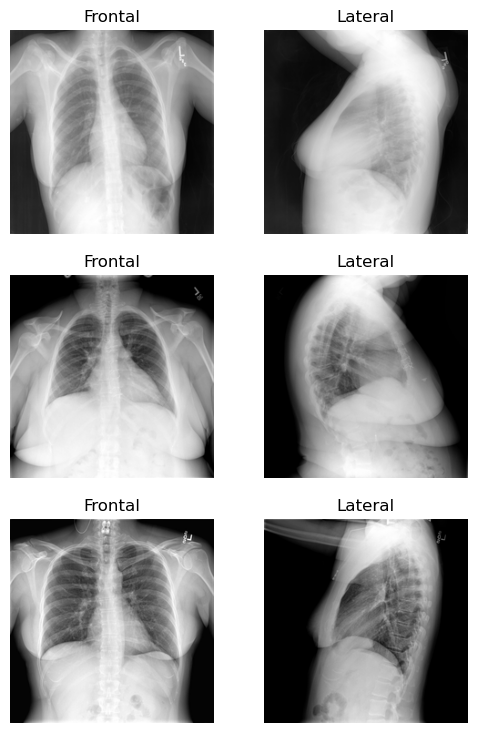

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(6, 9))

for i in range(3):
    axes[i, 0].imshow(data[i]["img_frontal_processed"])
    axes[i, 0].set_title("Frontal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(data[i]["img_lateral_processed"])
    axes[i, 1].set_title("Lateral")
    axes[i, 1].axis("off")

plt.show()

Each sample contains both frontal and lateral views, providing complementary perspectives of the chest.

While frontal images capture the overall lung structure, lateral views provide additional depth information that may help identify abnormalities not visible in a single view.

This multi-view setup suggests potential for multimodal or multi-input modeling approaches.

### Summary

Overall, the image data appears clean, standardized, and suitable for CNN-based modeling, with sufficient variability to capture clinically relevant patterns.

## Text EDA

In [ ]:
data = data.map(apply_refined_cleaning)

df = data.to_pandas()
print(f"Total samples: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

Map:   0%|          | 0/3388 [00:00<?, ? examples/s]

Total samples: 3388
Columns: ['uid', 'MeSH', 'Problems', 'image', 'indication', 'comparison', 'findings', 'impression', 'img_frontal', 'img_lateral', 'img_frontal_processed', 'img_lateral_processed', 'is_valid', 'findings_refined', 'impression_refined']


### Text Overview

In [ ]:
def word_count(text):
    if text is None or str(text).strip() == "":
        return 0
    return len(str(text).strip().split())

In [ ]:
df["findings_wc"]   = df["findings_refined"].apply(word_count)
df["impression_wc"] = df["impression_refined"].apply(word_count)

print("=== Text Column Summary ===")
summary = pd.DataFrame({
    "column": ["findings_refined", "impression_refined"],
    "total": [len(df), len(df)],
    "non_empty": [(df["findings_wc"] > 0).sum(), (df["impression_wc"] > 0).sum()],
    "missing": [(df["findings_wc"] == 0).sum(), (df["impression_wc"] == 0).sum()],
    "mean_words":[df[df["findings_wc"] > 0]["findings_wc"].mean().round(1),
                  df[df["impression_wc"] > 0]["impression_wc"].mean().round(1)],
    "median_words": [df[df["findings_wc"]  > 0]["findings_wc"].median(),
                    df[df["impression_wc"] > 0]["impression_wc"].median()],
    "max_words": [df["findings_wc"].max(), df["impression_wc"].max()],
})

print(summary.to_string(index=False))

=== Text Column Summary ===
            column  total  non_empty  missing  mean_words  median_words  max_words
  findings_refined   3388       2943      445        31.0          29.0        149
impression_refined   3388       3370       18        10.1           5.0        133


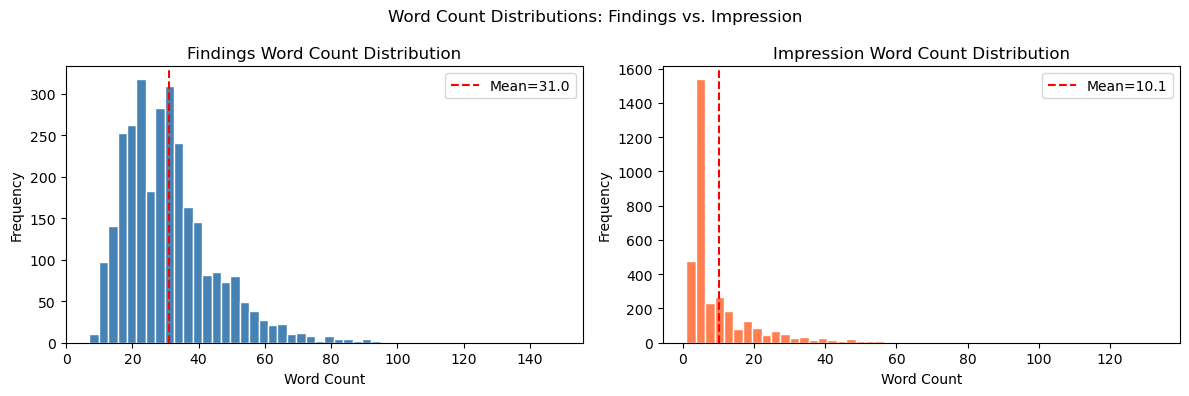

In [ ]:
findings_mean = df[df["findings_wc"] > 0]["findings_wc"].mean()
impression_mean = df[df["impression_wc"] > 0]["impression_wc"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df[df["findings_wc"] > 0]["findings_wc"], bins=50,
             color="steelblue", edgecolor="white")
axes[0].set_title("Findings Word Count Distribution")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].axvline(findings_mean, color="red", linestyle="--", label=f"Mean={findings_mean:.1f}")
axes[0].legend()

axes[1].hist(df[df["impression_wc"] > 0]["impression_wc"], bins=50,
             color="coral", edgecolor="white")
axes[1].set_title("Impression Word Count Distribution")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].axvline(impression_mean, color="red", linestyle="--", label=f"Mean={impression_mean:.1f}")
axes[1].legend()

plt.suptitle("Word Count Distributions: Findings vs. Impression")
plt.tight_layout()
plt.show()

For the two description columns that could potentially be used as the generation ground-truth, 'findings' and 'impression', in the cleaned dataset, which has also been stripped of numbering, the summary and distributions above reveal some key insights. The findings word count distribution is approximately bell-shaped, centered around its mean of 31 words (among only non-empty samples) with a modest right tail extending to 100 words, indicating that findings are consistently verbose across samples. In contrast, the impression distribution is heavily right-skewed as the tallest bar sits near 0-5 words with frequency exceeding 1,500, dropping sharply afterward, confirming that the vast majority of impressions are very short single-sentence conclusions while a small subset of pathological cases produce notably longer multi-finding outputs that pull the mean up to 10.1.

More importantly, findings has 445 missing values (13%) compared to only 18 (0.5%) for impression. This missingness in findings is not addressed by the image-based filtering applied in preprocessing, where samples were only filtered on image validity, not text completeness.  As a result, using findings as a generation target would either discard 13% of the dataset or require imputation.

These observations jointly motivate using impression as the generation target for out redefined task as it is more complete, more concise and structured, and clinically more meaningful as the radiologist's final actionable conclusion.

In [ ]:
missing_matrix = pd.DataFrame({
    "findings_missing": df["findings_wc"] == 0,
    "impression_missing": df["impression_wc"] == 0,
})

print(f"\nMissing findings but have impression: "
      f"{(missing_matrix['findings_missing'] & ~missing_matrix['impression_missing']).sum()}")
print(f"Missing both: "
      f"{(missing_matrix['findings_missing'] & missing_matrix['impression_missing']).sum()}")


Missing findings but have impression: 433
Missing both: 12


Of the 445 samples missing findings, 433 (97.3%) still have a valid impression, and only 12 samples are missing both. This confirms that impression is a far more reliable target column as it is present even when findings are absent, suggesting that radiologists prioritized writing the
clinical conclusion over the detailed observations in some cases. This further solidifies the choice of impression as the generation target.

In [ ]:
numbered = df[df["impression"].str.contains(r'^\s*1[\.\)]', na=False, regex=True)]
print(f"Total numbered impressions: {len(numbered)}")
print(numbered[["impression", "impression_refined"]][2:3].to_string())

Total numbered impressions: 655
                                                                                                                                                                                                                                                                           impression                                                                                                                                                                                                                                                               impression_refined
27  1. Interval improvement in consolidative left base opacity. Multifocal scattered bibasilar patchy and XXXX pulmonary opacities again noted, most consistent with atelectasis/infiltrate. 2. Stable enlarged cardiomediastinal silhouette. Stable pulmonary vascular congestion. .  Interval improvement in consolidative left base opacity. Multifocal scattered bibasilar patchy and XXXX pulmonary opacities again noted, m

One limitation of the current text preprocessing is the inconsistent use of '[SEP]' tag across samples. Approximately 19% of impression originally contained numbered findings (e.g., "1. Cardiomegaly. 2. Pleural effusion."), corresponding to samples where radiologists originally enumerated multiple distinct findings, which were converted to '[SEP]'-delimited boundaries during preprocessing. The remaining impressions contain a single finding and therefore require no separator. This means '[SEP]' is semantically meaningful where present, but its absence simply indicates a single-finding impression. The primary open question for following training is whether to retain '[SEP]' as a special token or normalize to flat text, depending on the final model architecture chosen.

### XXXX Tokens

In [ ]:
def count_xxxx(text):
    if text is None:
        return 0
    return len(re.findall(r'XXXX', str(text), re.IGNORECASE))

df["xxxx_findings"] = df["findings_refined"].apply(count_xxxx)
df["xxxx_impression"] = df["impression_refined"].apply(count_xxxx)

print("=== XXXX Token Summary ===")
print(f"Samples with XXXX in findings: {(df['xxxx_findings'] > 0).sum()} "
      f"({(df['xxxx_findings'] > 0).mean():.1%})")
print(f"Samples with XXXX in impression: {(df['xxxx_impression'] > 0).sum()} "
      f"({(df['xxxx_impression'] > 0).mean():.1%})")
print(f"\nMean XXXX per findings sample: {df[df['xxxx_findings']   > 0]['xxxx_findings'].mean():.2f}")
print(f"Mean XXXX per impression sample: {df[df['xxxx_impression'] > 0]['xxxx_impression'].mean():.2f}")

=== XXXX Token Summary ===
Samples with XXXX in findings: 1220 (36.0%)
Samples with XXXX in impression: 548 (16.2%)

Mean XXXX per findings sample: 1.65
Mean XXXX per impression sample: 1.76


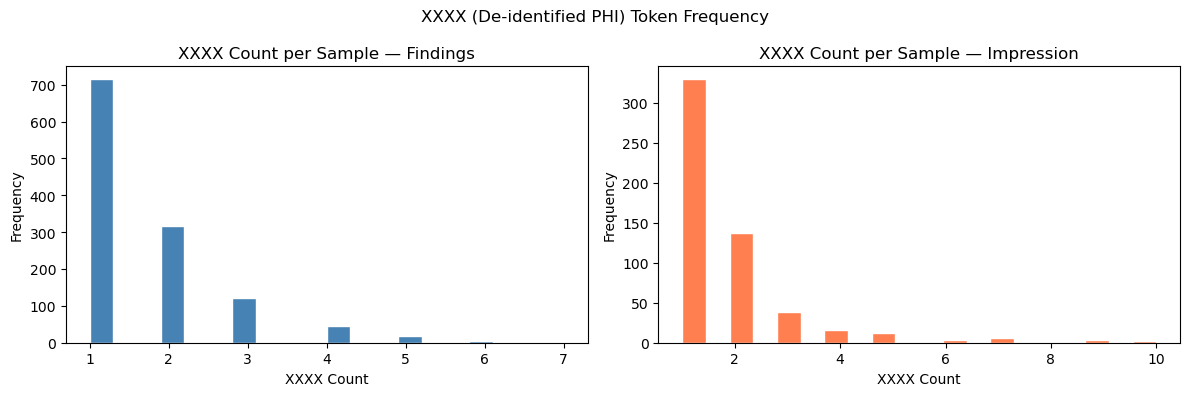

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[df["xxxx_findings"] > 0]["xxxx_findings"], bins=20,
             color="steelblue", edgecolor="white")
axes[0].set_title("XXXX Count per Sample — Findings")
axes[0].set_xlabel("XXXX Count")
axes[0].set_ylabel("Frequency")

axes[1].hist(df[df["xxxx_impression"] > 0]["xxxx_impression"], bins=20,
             color="coral", edgecolor="white")
axes[1].set_title("XXXX Count per Sample — Impression")
axes[1].set_xlabel("XXXX Count")
axes[1].set_ylabel("Frequency")

plt.suptitle("XXXX (De-identified PHI) Token Frequency")
plt.tight_layout()
plt.show()

XXXX tokens serve as placeholders for de-identified protected health information (PHI), such as patient names, ages, and dates, appearing in 36% of findings samples and 16% of impression samples. The higher prevalance in findings is expected since findings are more verbose and more likely to reference patient-specific contextual information.

Both distributions are heavily concentrated at low counts (1-2 XXXX tokens per sample), with frequency dropping sharply beyond that. Findings extend up to 7 XXXX tokens while impressions reach up to 10, though these high counts are extremely rare.

For model training, XXXX tokens in the target (impression) can be problematic as the model would need to learn to generate XXXX as an output token, which is meaningless and potentially misleading. A practical decision would be to strip XXXX from impression targets entirely before training, or replace them with a generic placeholder the tokenizer natively supports.

In [ ]:
def get_corpus(series):
    all_text = " ".join([str(x) for x in series.dropna() if word_count(x) > 0])
    # remove XXXX and SEP tokens for vocabulary analysis
    all_text = re.sub(r'XXXX', '', all_text, flags=re.IGNORECASE)
    all_text = re.sub(r'\[SEP\]', '', all_text)
    return all_text

def vocab_size(text):
    words = re.findall(r'\b[a-z]{2,}\b', text.lower())
    return len(set(words)), len(words)

def top_words(text, n=20):
    words = re.findall(r'\b[a-z]{3,}\b', text.lower())
    words = [w for w in words if w not in STOPWORDS]
    return Counter(words).most_common(n)

In [ ]:
findings_text = get_corpus(df["findings_refined"])
impression_text = get_corpus(df["impression_refined"])

findings_unique, findings_total = vocab_size(findings_text)
impression_unique, impression_total = vocab_size(impression_text)

print("=== Vocabulary Summary ===")
print(f"Findings — unique tokens: {findings_unique:,}, total tokens: {findings_total:,}")
print(f"Impression — unique tokens: {impression_unique:,}, total tokens: {impression_total:,}")

=== Vocabulary Summary ===
Findings   — unique tokens: 1,475, total tokens: 88,661
Impression — unique tokens: 1,384, total tokens: 32,632


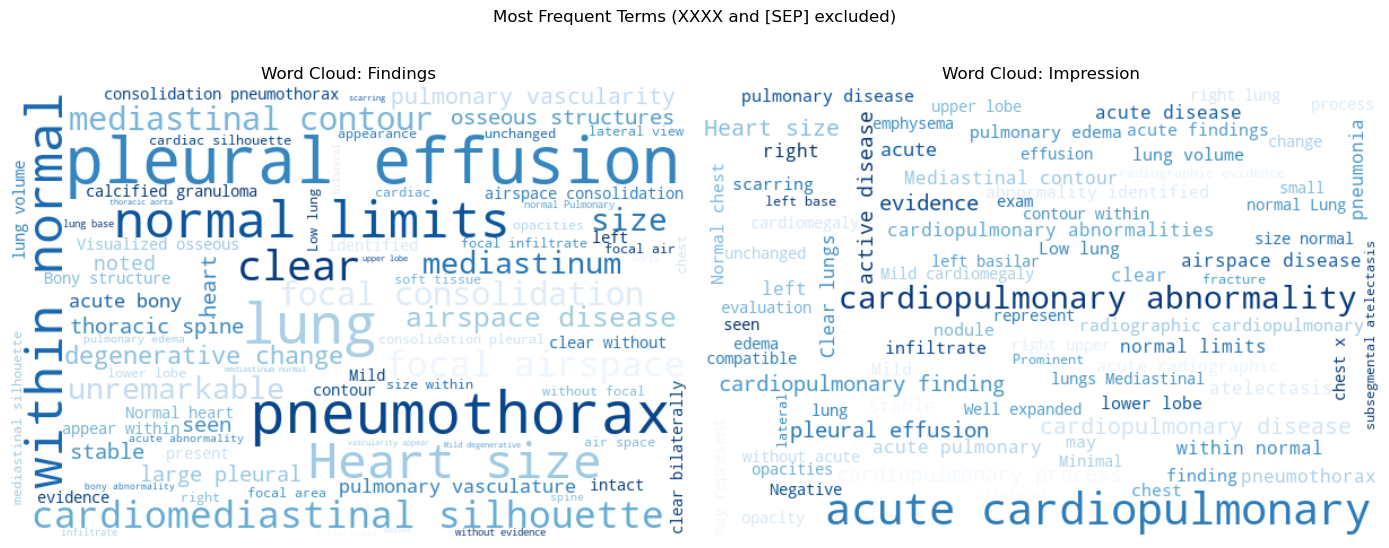

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, text, title in zip(axes,
                            [findings_text, impression_text],
                            ["Findings", "Impression"]):
    wc = WordCloud(width=600, height=400,
                   background_color="white",
                   colormap="Blues",
                   max_words=80).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Word Cloud: {title}")

plt.suptitle("Most Frequent Terms (XXXX and [SEP] excluded)")
plt.tight_layout()
plt.show()

The vocabulary analysis reveals clear differences in language style between the two text columns. Findings uses 1,475 unique tokens across 88,661 total tokens, while impression uses 1,384 unique tokens across only 32,632 total tokens. Despite having a similar vocabulary size, impression uses far fewer total words， confirming its concise, formulaic nature.

The word clouds further illustrate this contrast. Findings vocabulary is dominated by specific anatomical descriptors and observations: "pleural effusion", "pneumothorax", "focal consolidation", "cardiomediastinal silhouette", and "osseous structures" — detailed radiological observations
that describe what is seen in the image. In contrast, impression vocabulary centers around conclusive clinical language: "acute cardiopulmonary", "cardiopulmonary abnormality", "clear lungs", "heart size", and "pleural effusion", which are shorter, more standardized phrases that summarize the bottom-line clinical conclusion.

This distinction is important for model training. The impression vocabulary is smaller and more formulaic, meaning the generation model needs to learn a more constrained output space compared to findings. The high frequency of phrases like "no acute cardiopulmonary process" and "clear lungs" in the impression cloud also visually confirms the class imbalance noted earlier: a large proportion of impressions describe normal or unremarkable findings, which the model will need to handle carefully to avoid defaulting to generic normal outputs for all inputs.

## Redefinition & Rescoping of the Problem Statement

## Next Step

## Future Consideration